In [2]:
import matplotlib.pyplot as plt
import numpy as np
import mne
import library.config as C
import library.mtmvar as mvar
import pandas as pd

In [3]:
from mne.io import read_raw_edf
from mne.channels import make_standard_montage, find_ch_adjacency

## read edfs of eegs included in preprocessed metadata csvs

In [4]:
eeg_dir = C.EDF_DIR
dataset = "ELM19"
meta_df = pd.read_csv(f'{C.BASE_DIR}/magisterka/metadata/metadata_exams.csv')
exams = meta_df['exam_id'].to_list()
paths = [eeg_dir + f"/{exam}.edf" for exam in exams]

In [5]:
meta_df["epochs"] = 0 
meta_df["bad_epochs"] = None

In [8]:
def create_path_from_idx(idx: int) -> str:
    return eeg_dir + f"/{exams[idx]}.edf"

def read_raw_eeg_from_edf_path(path: str) -> mne.io.BaseRaw:
    return read_raw_edf(path, 
                        infer_types = True,
                        exclude = ['A1', 'A2', 'EKG-REF', 'Photic-REF'],
                        verbose = 0,
                        preload = True)

In [13]:
p0 = create_path_from_idx(14)
raw0 = read_raw_eeg_from_edf_path(p0)

## read and save basic exam info

In [14]:
print("This recording has {} channels of type {} and {} samples with a sampling frequency of {} Hz".format(raw0.info['nchan'], 'eeg' if 'eeg' in raw0 else 'other', raw0.n_times, raw0.info['sfreq']))
print("The recording lasts {} minutes".format(raw0.n_times / raw0.info['sfreq']/60))

This recording has 30 channels of type eeg and 256500 samples with a sampling frequency of 250.0 Hz
The recording lasts 17.1 minutes


In [15]:
raw0.info['subject_info']["his_id"] = meta_df["sub_id"].iloc[0]
raw0.info['subject_info']["sex"] = int(meta_df["female"].iloc[0])
raw0.info['description'] = str(meta_df["pathology"].iloc[0])

In [16]:
raw0.describe()

<RawEDF | 20220412-174557-{8c951a70-8a97-46d9-a574-2421a036bcd5}.edf, 30 x 256500 (1026.0 s), ~58.7 MiB, data loaded>
ch  name  type  unit        min         Q1     median         Q3        max
 0  Fp1   EEG   µV     -1290.34    -104.65     -65.11     -27.01     333.46
 1  Fp2   EEG   µV     -1581.75    -160.10    -119.32     -82.47     381.58
 2  F7    EEG   µV      -906.79    -200.35    -161.54    -122.54     939.54
 3  F3    EEG   µV     -1217.35       7.87      43.83      81.40     416.10
 4  Fz    EEG   µV     -1444.18     -94.45     -56.88     -20.03     303.76
 5  F4    EEG   µV     -1473.70     -60.46     -22.36      15.57     382.11
 6  F8    EEG   µV     -1504.29     -54.02      -8.76      38.29     420.93
 7  T3    EEG   µV      -702.32    -146.69    -104.47     -61.71    2318.07
 8  C3    EEG   µV     -1274.77     -30.95       5.19      43.29     295.53
 9  Cz    EEG   µV     -1642.75    -165.83    -127.73     -89.80     260.83
10  C4    EEG   µV     -1449.01     -35.42    

# set standard montage

In [63]:
montage = make_standard_montage("standard_1020")
raw0.set_montage(montage, match_case=False, on_missing='ignore')

<RawEDF | 20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f85c97c5}.edf, 19 x 300000 (1200.0 s), ~43.5 MiB, data loaded>

In [64]:
for mapping in C.CHNAMES_MAPPING:
    if set(mapping.keys()).issubset(set(raw0.ch_names)):
        raw0.rename_channels(mapping)

In [65]:
from scipy.signal import butter, iirnotch, sosfiltfilt, filtfilt, buttord


def apply_filters(self, plot_psd=False):
        raw = self
        sfreq = raw.info["sfreq"]

        if plot_psd:
            print("PSD before")
            g = raw.compute_psd().plot(picks="eeg", show=True)
            

        if C.DEFAULT_NOTCH_FREQ is not None:
            b, a = iirnotch(C.DEFAULT_NOTCH_FREQ, C.DEFAULT_NOTCH_Q, fs=sfreq)
            raw.apply_function(lambda d: filtfilt(b, a, d, axis=-1), verbose=False)

        wp_hp = C.DEFAULT_HP_CUTOFF
        ws_hp = wp_hp * 0.5
        N_hp, Wn_hp = buttord(wp=wp_hp, ws=ws_hp, gpass=C.DEFAULT_GPASS, gstop=C.DEFAULT_GSTOP, fs=sfreq)
        sos_hp = butter(min(N_hp, C.DEFAULT_MAX_ORDER), Wn_hp, btype="highpass", fs=sfreq, output="sos")
        raw.apply_function(lambda d: sosfiltfilt(sos_hp, d, axis=-1), verbose=False)

        wp_lp = C.DEFAULT_LP_CUTOFF
        ws_lp = wp_lp + (wp_lp * 0.25)
        N_lp, Wn_lp = buttord(wp=wp_lp, ws=ws_lp, gpass=C.DEFAULT_GPASS, gstop=C.DEFAULT_GSTOP, fs=sfreq)
        sos_lp = butter(min(N_lp, C.DEFAULT_MAX_ORDER), Wn_lp, btype="lowpass", fs=sfreq, output="sos")
        raw.apply_function(lambda d: sosfiltfilt(sos_lp, d, axis=-1), verbose=False)

        with raw.info._unlock():
            raw.info["highpass"] = C.DEFAULT_HP_CUTOFF
            raw.info["lowpass"] = C.DEFAULT_LP_CUTOFF

        if plot_psd:
            print("PSD after")
            g = raw.compute_psd().plot(picks="eeg", show=True)

        self.raw = raw

        return self

In [66]:
apply_filters(raw0,True)

PSD before
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
PSD after
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


<RawEDF | 20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f85c97c5}.edf, 19 x 300000 (1200.0 s), ~43.5 MiB, data loaded>

## explore montage

In [67]:
raw0.info['dig']

[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>,
 <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>,
 <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>,
 <DigPoint |     EEG #1 : (-30.9, 114.6, 27.9) mm   : head frame>,
 <DigPoint |     EEG #3 : (28.4, 115.3, 27.7) mm    : head frame>,
 <DigPoint |    EEG #16 : (-71.9, 73.1, 25.8) mm    : head frame>,
 <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>,
 <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>,
 <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>,
 <DigPoint |    EEG #24 : (71.4, 74.5, 25.1) mm     : head frame>,
 <DigPoint |    EEG #40 : (-67.1, 23.4, 104.5) mm   : head frame>,
 <DigPoint |    EEG #42 : (-1.4, 27.6, 140.2) mm    : head frame>,
 <DigPoint |    EEG #44 : (65.3, 23.6, 103.7) mm    : head frame>,
 <DigPoint |    EEG #62 : (-55.0, -44.2, 99.9) mm   : head frame>,
 <DigPoint |    EEG #64 : (-1.7, -45.2, 126.7) mm   : head fra

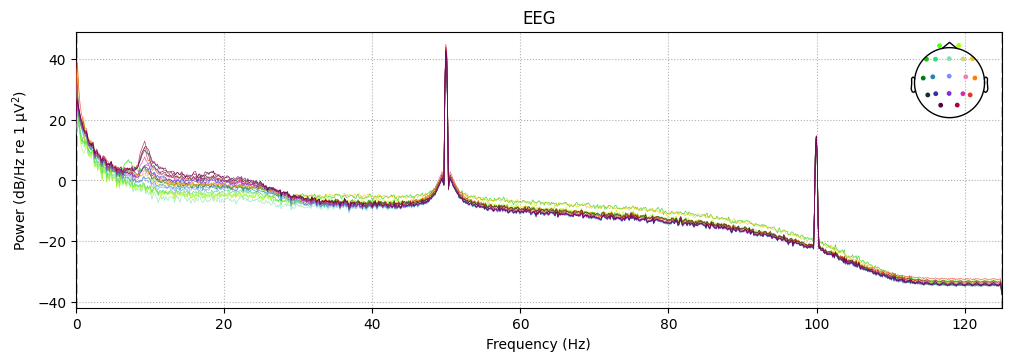

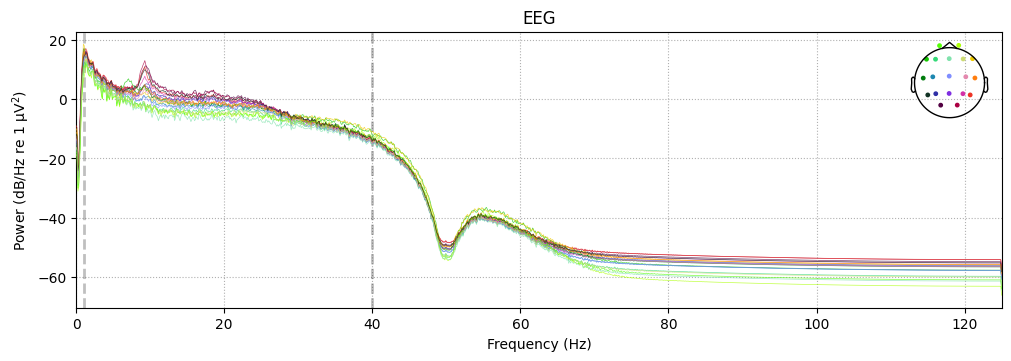

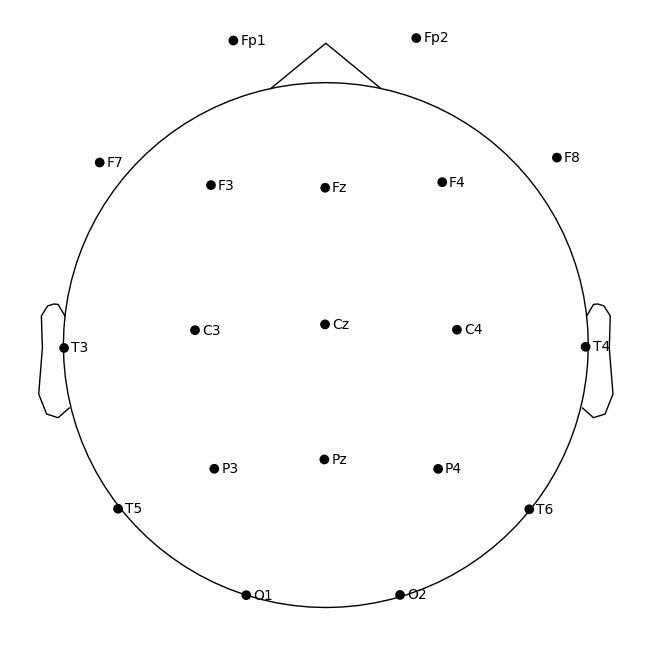

In [68]:
g = raw0.plot_sensors(
    show_names=True,
    ch_type="eeg",
    kind="topomap",
    to_sphere=True,
    sphere="eeg")


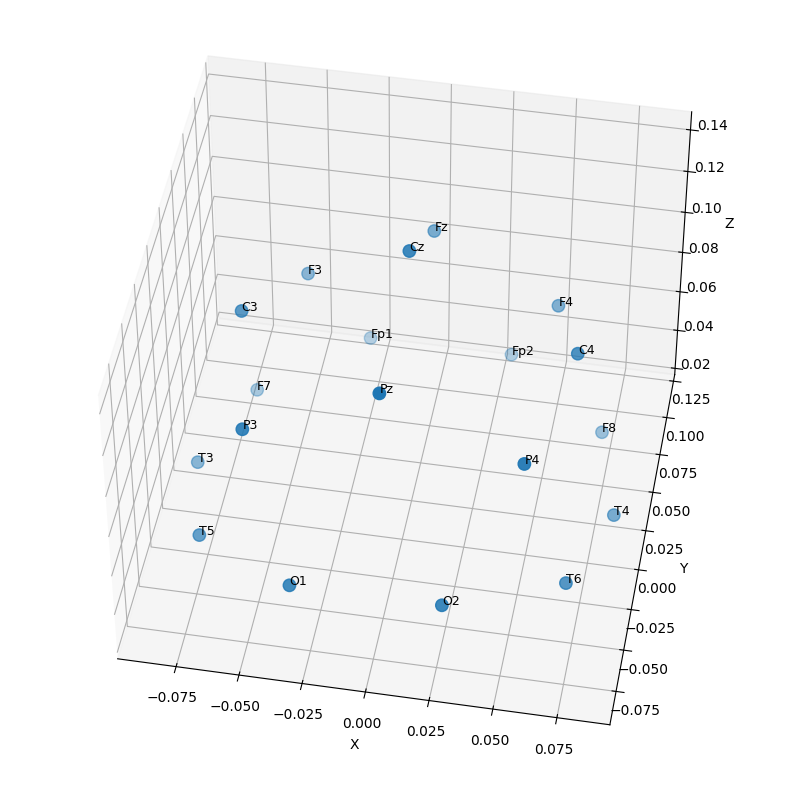

In [69]:
pos = raw0._get_channel_positions()

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

ax.scatter(*pos.T, s=80)

for ch, xyz in zip(raw0.ch_names, pos):
    ax.text(*xyz, ch, fontsize=9) #type:ignore

ax.set(xlabel='X', ylabel='Y', zlabel='Z')
ax.view_init(elev=45, azim=-80)

plt.show()

## re -reference, -sample & drop ref channels

In [70]:
raw0.set_eeg_reference(ref_channels = C.LINKED_TEMPORAL) #type:ignore

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


<RawEDF | 20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f85c97c5}.edf, 19 x 300000 (1200.0 s), ~43.5 MiB, data loaded>

In [71]:
raw0.resample(float(C.DEFAULT_SFREQ))

<RawEDF | 20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f85c97c5}.edf, 19 x 153600 (1200.0 s), ~22.3 MiB, data loaded>

For connectivity analysis, reference channels need to be dropped

In [72]:
raw0.drop_channels(C.LINKED_TEMPORAL)

<RawEDF | 20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f85c97c5}.edf, 17 x 153600 (1200.0 s), ~19.9 MiB, data loaded>

## spatial adjacency matrix of channels after pruning (removing reference linked ears channels)
https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_array.html#scipy.sparse.csr_array

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 17


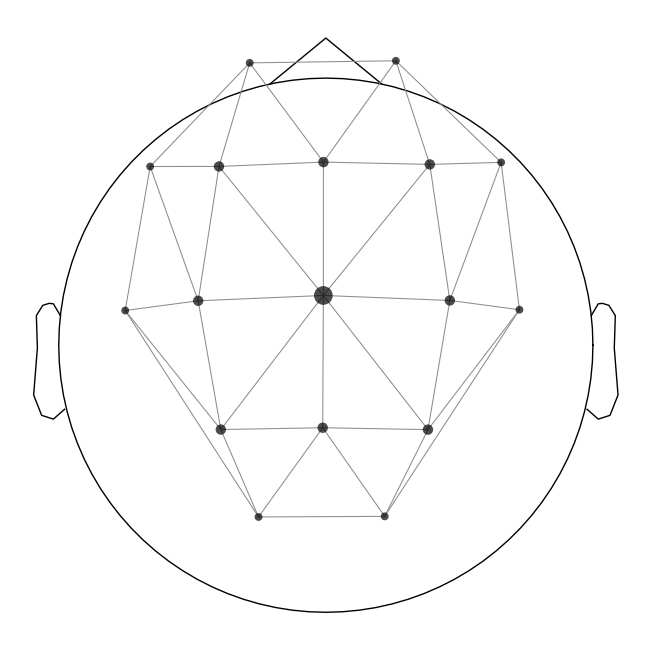

In [73]:
ch_adjacency, ch_names = find_ch_adjacency(raw0.info, ch_type = "eeg")
mne.viz.plot_ch_adjacency(raw0.info, ch_adjacency, ch_names)

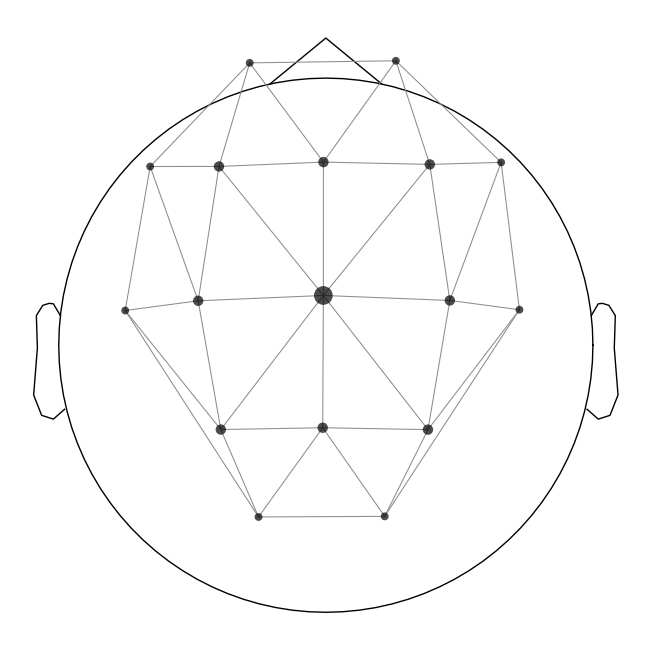

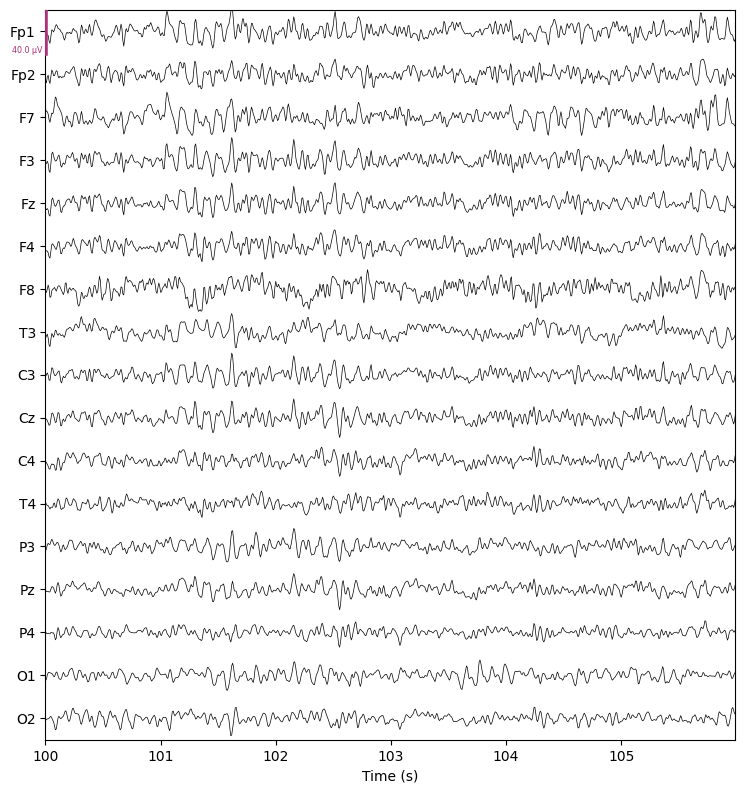

In [74]:
g = raw0.plot(block = True, start = 100, duration = 6, show_scrollbars = False, remove_dc = True)


## events & epochs
https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html

Used Annotations descriptions: [np.str_('Eyes_Closed'), np.str_('Eyes_Opened'), np.str_('Recording ends'), np.str_('Recording starts'), np.str_('Stimulation_HyperventilationStart'), np.str_('Stimulation_HyperventilationStop'), np.str_('Stimulation_PhotostimulationStart'), np.str_('Stimulation_PhotostimulationStop')]


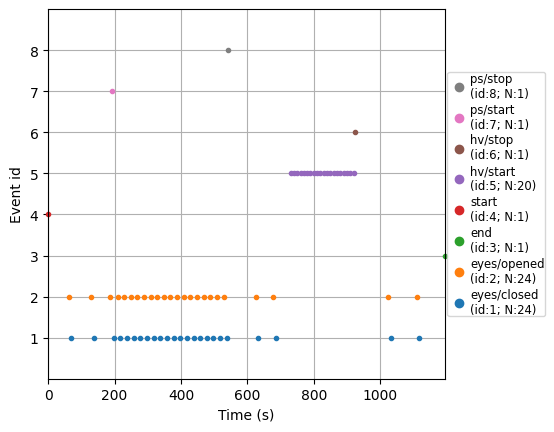

In [75]:
all_events, all_event_id = mne.events_from_annotations(raw0)
event_dict = {"eyes/closed":1, "eyes/opened":2, "end": 3, "start": 4, "hv/start":5, "hv/stop":6, "ps/start":7, "ps/stop":8}
g = mne.viz.plot_events(events=all_events, event_id=event_dict, sfreq=raw0.info["sfreq"])


In [76]:
all_event_id

{np.str_('Eyes_Closed'): 1,
 np.str_('Eyes_Opened'): 2,
 np.str_('Recording ends'): 3,
 np.str_('Recording starts'): 4,
 np.str_('Stimulation_HyperventilationStart'): 5,
 np.str_('Stimulation_HyperventilationStop'): 6,
 np.str_('Stimulation_PhotostimulationStart'): 7,
 np.str_('Stimulation_PhotostimulationStop'): 8}

In [77]:
epochs = mne.Epochs(raw0, all_events, tmin=-0.3, tmax=0.7)

Not setting metadata
73 matching events found
Setting baseline interval to [-0.296875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


In [78]:
print(epochs)

<Epochs | 73 events (good & bad), -0.297 – 0.703 s (baseline -0.297 – 0 s), ~26 KiB, data not loaded,
 '1': 24
 '2': 24
 '3': 1
 '4': 1
 '5': 20
 '6': 1
 '7': 1
 '8': 1>


In [79]:
print(epochs.event_id)

{'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8}


In [80]:
event_dict = {"eyes/closed":1, "eyes/opened":2, "end": 3, "start": 4, "hv/start":5, "hv/stop":6, "ps/start":7, "ps/stop":8}

In [81]:
epochs = mne.Epochs(raw0, all_events, tmin=-0.3, tmax=0.7, event_id=event_dict, preload=True)
print(epochs.event_id)

Not setting metadata
73 matching events found
Setting baseline interval to [-0.296875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 73 events and 129 original time points ...
1 bad epochs dropped
{'eyes/closed': 1, 'eyes/opened': 2, 'end': 3, 'start': 4, 'hv/start': 5, 'hv/stop': 6, 'ps/start': 7, 'ps/stop': 8}


In [82]:
print(epochs.drop_log[:])

(('NO_DATA',), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), ())


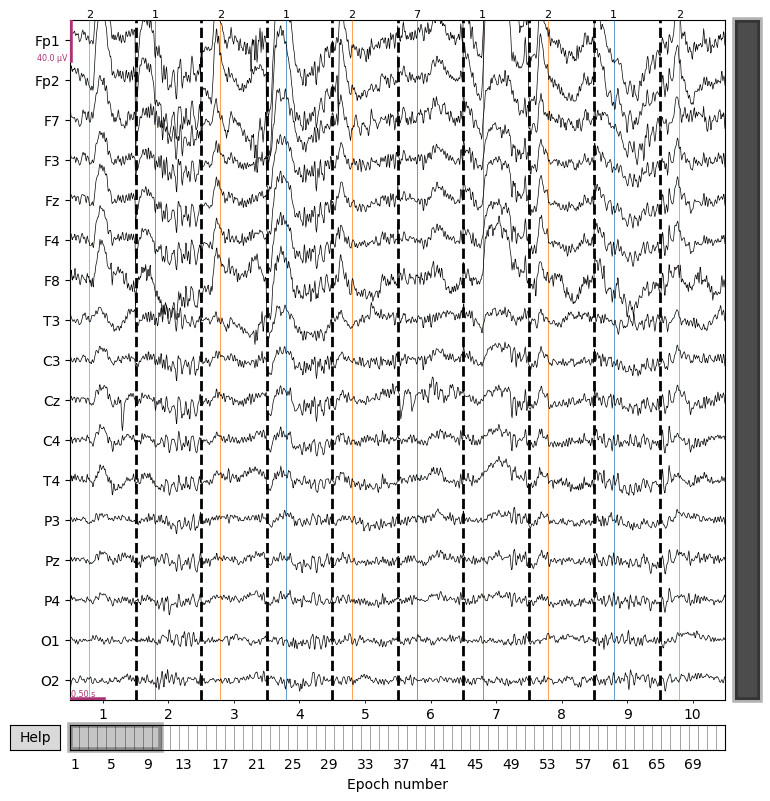

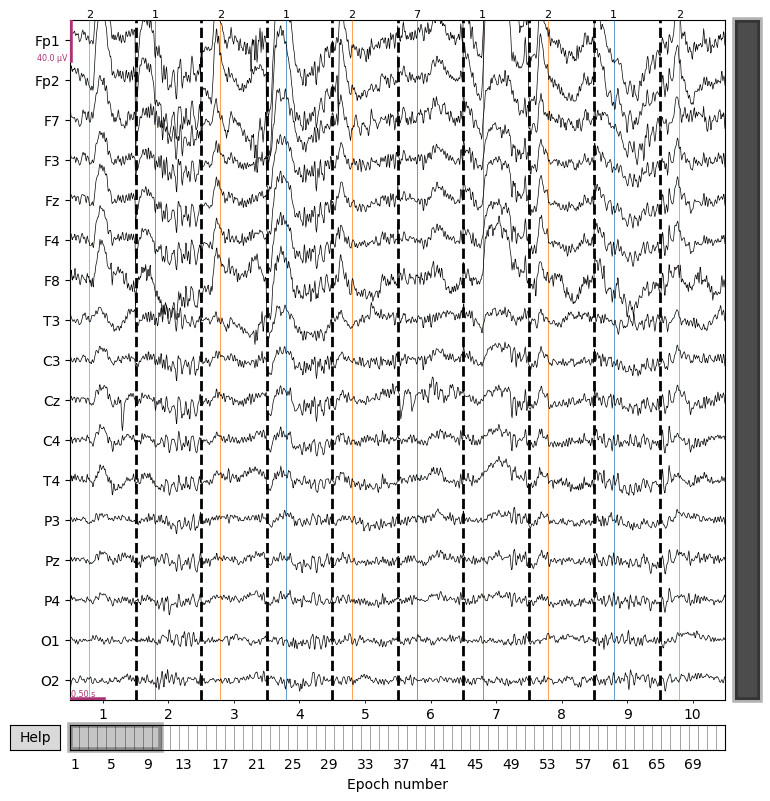

In [83]:
epochs.plot(n_epochs=10, events=True)

In [84]:
try:
    print(epochs[["eyes/opened", "eyes/closed"]])
except KeyError:
    print("Tag-based selection with no matches raises a KeyError!")

<Epochs | 48 events (all good), -0.297 – 0.703 s (baseline -0.297 – 0 s), ~849 KiB, data loaded,
 'eyes/closed': 24
 'eyes/opened': 24>


## segmenting into equal-sized consequtive epochs

I'm using make_fixed_length_events and not make_fixed_length_epochs, because make_fixed_length_events don't have reject & flat (PTP rejection criteria) parameters.

In [85]:
#create events of fixed length (frames/ segments)
epoch_events = mne.make_fixed_length_events(raw0, 
                                      duration = 6,
                                      overlap = 0)

# instantiate epochs with PTP amplitude rejection criterion
epochs = mne.Epochs(raw0,
                    events = epoch_events,
                    tmax = 6.0)

epochs.drop_bad(reject = dict(eeg = 800e-6), #type:ignore
                flat = dict(eeg = 1e-6)) #type:ignore

Not setting metadata
200 matching events found
Setting baseline interval to [-0.203125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 200 events and 795 original time points ...
2 bad epochs dropped


<Epochs | 198 events (all good), -0.203 – 6 s (baseline -0.203 – 0 s), ~26 KiB, data not loaded,
 '1': 198>

In [86]:
drop_counts = pd.Series([reason for log in epochs.drop_log for reason in log]).value_counts().to_dict()

In [87]:
meta_df.at[0, "epochs"] = len(epochs)
meta_df.at[0, "bad_epochs"] = drop_counts #type:ignore

meta_df.head()

,site,sub_id,exam_id,age,age_group,female,pathology,epochs,bad_epochs
0,S17,sub-000,20220411-162228-{4fe29d03-5025-46ca-8e14-c3b3f...,56.6,56-65,0,0,198,"{'NO_DATA': 1, 'TOO_SHORT': 1}"
1,S12,sub-001,20220510-150544-{cc1f09f8-3b30-40b4-91f8-4cd70...,38.0,36-45,0,1,0,None
2,S01,sub-002,20220412-172841-{0881d6c7-8c23-4389-87c1-58c8e...,20.4,16-25,0,1,0,None
3,S23,sub-003,20220530-182538-{85ec4ff0-fd03-4be2-a44b-99723...,23.6,16-25,1,1,0,None
4,S00,sub-004,20220512-152511-{61074308-a109-40b1-97cb-43dcb...,60.6,56-65,0,1,0,None


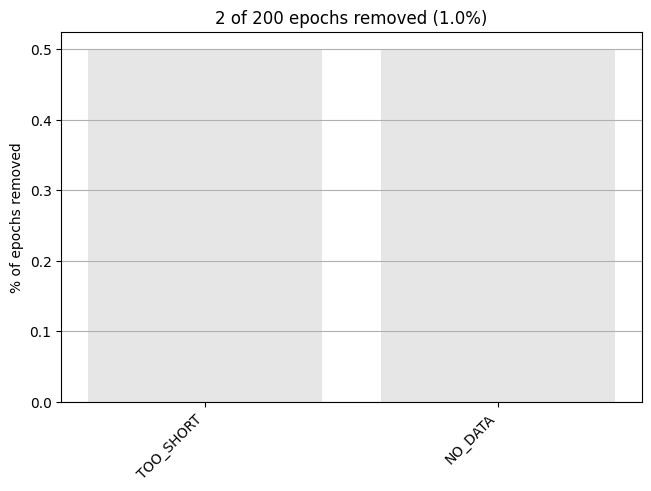

In [88]:
_ = epochs.plot_drop_log()

Using data from preloaded Raw for 198 events and 795 original time points ...
Not setting metadata
198 matching events found
No baseline correction applied
0 projection items activated


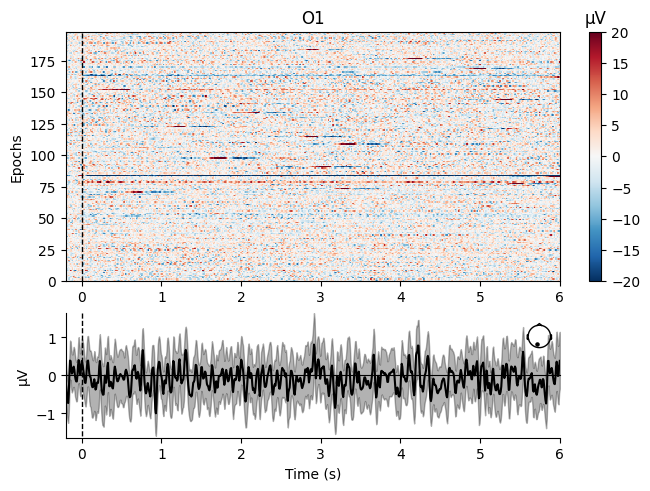

[<Figure size 640x480 with 4 Axes>]

In [89]:
epochs.plot_image(picks = ["O1"],
                  vmin = - 20,
                  vmax = 20)

Using data from preloaded Raw for 198 events and 795 original time points ...
    Using multitaper spectrum estimation with 7 DPSS windows


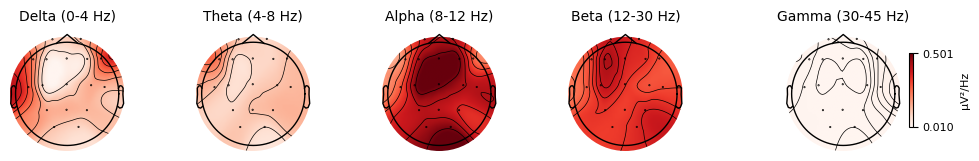

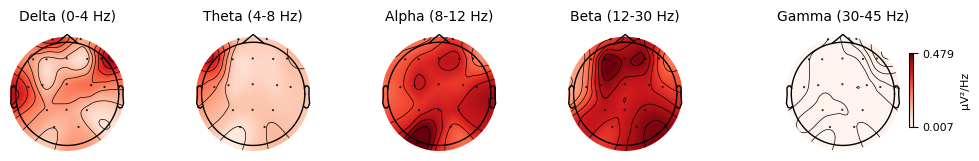

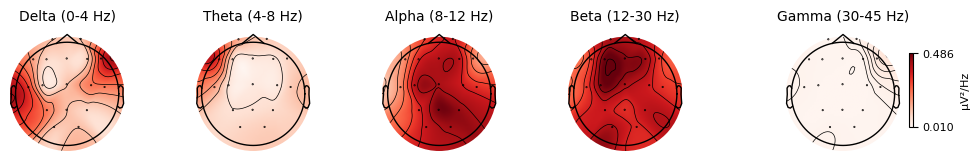

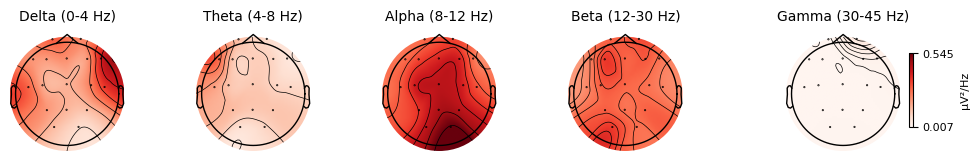

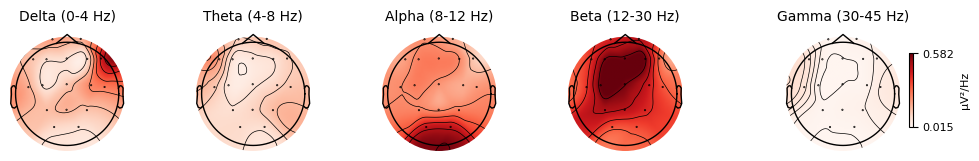

In [90]:
psd = epochs.compute_psd(fmin=1, fmax=40)
epoch_indices = [0, len(epochs)//4, len(epochs)//2, 3*len(epochs)//4, len(epochs)-1]
for epoch_idx in epoch_indices:
    g = psd[epoch_idx].plot_topomap(normalize=True, vlim="joint")
    g.suptitle(f"Epoch {epoch_idx} - Normalized PSD")


Finally, I gave up on Autoreject. Maybe i'll come back to it later, but it doesn't seem so relevant to the study, while being heavy on computations.

In [91]:
X = epochs.get_data()[:100]

Using data from preloaded Raw for 198 events and 795 original time points ...


In [92]:
sig = X[0]
sig

array([[ 9.71570553e-06,  1.21277973e-05,  1.17723009e-05, ...,
        -5.11589838e-06, -5.38695598e-06, -6.44366134e-06],
       [ 1.22853485e-05,  1.68548532e-05,  1.73625492e-05, ...,
        -3.28577572e-08,  3.47185152e-07, -8.29003993e-07],
       [ 3.74948836e-06,  5.47127595e-06,  6.27437192e-06, ...,
        -5.59707988e-06, -5.36157590e-06, -6.64499113e-06],
       ...,
       [ 3.32782774e-06,  2.27366941e-06, -1.54614926e-07, ...,
        -4.37828387e-06, -5.38431057e-06, -5.07447912e-06],
       [-2.42738588e-06, -1.81603614e-06, -7.60607741e-07, ...,
         1.55757488e-06,  6.55291981e-07,  2.12213828e-06],
       [-2.79410579e-06, -3.55552621e-06, -3.86917370e-06, ...,
         6.88836579e-06,  9.79317548e-06,  1.36786261e-05]],
      shape=(17, 795))

https://braindecode.org/dev/auto_examples/applied_examples/plot_tuh_eeg_corpus.html

https://www.youtube.com/watch?v=LwxpDInax44

In [93]:
sig_zscored = mvar.zscore_per_channel(sig)

In [94]:
sig_zscored

array([[ 2.03947122,  2.3856258 ,  2.33460921, ..., -0.08898335,
        -0.1278823 , -0.27952803],
       [ 1.70720411,  2.36476605,  2.43782463, ..., -0.0654133 ,
        -0.01072428, -0.17998053],
       [ 1.23701929,  1.46840414,  1.57632932, ..., -0.01903245,
         0.01261608, -0.15985748],
       ...,
       [ 1.21668654,  0.94211131,  0.30961929, ..., -0.79051418,
        -1.05255263, -0.97185124],
       [-0.60226109, -0.43660547, -0.15061917, ...,  0.47753189,
         0.23304297,  0.63050996],
       [-0.7389825 , -0.92439736, -1.00077422, ...,  1.61881355,
         2.32616898,  3.27232204]], shape=(17, 795))

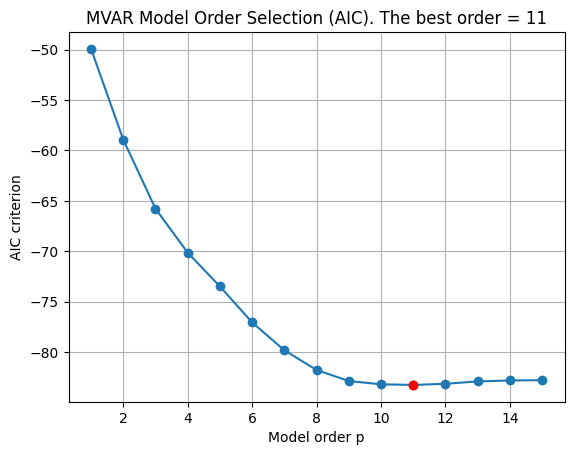

(array([-49.92639685, -58.93388829, -65.77656358, -70.13920749,
        -73.48861625, -77.0570599 , -79.82133453, -81.77786836,
        -82.86956643, -83.20092052, -83.26068866, -83.15087193,
        -82.91311765, -82.81802589, -82.78670729]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 np.int64(11))

In [95]:
mvar.mvar_criterion(sig_zscored, max_p = 15, crit_type='AIC', do_plot=True)

In [96]:
AR, Vr = mvar.AR_coeff(sig_zscored, p = 11)

In [97]:
FREQS = np.arange(C.DEFAULT_HP_CUTOFF, C.DEFAULT_LP_CUTOFF + 1, 1)
H, _ = mvar.mvar_H(AR, FREQS, raw0.info['sfreq'])

In [98]:
H

array([[[ 2.31134925e+01-1.28725456e+01j,
          9.51599046e+00-6.64972278e+00j,
          1.02408253e+01-8.58168012e+00j, ...,
         -1.17803466e+00-1.70135917e-01j,
         -7.70595225e-01+3.11678991e-01j,
         -2.34531137e-01+2.18459027e-01j],
        [-9.87174411e+00+4.38667219e+00j,
          4.77118093e-01+3.23651222e+00j,
         -1.11347918e+00+2.26582543e+00j, ...,
         -9.48041968e-01+4.29167022e-01j,
         -6.28474785e-01+6.90179898e-01j,
         -3.43310392e-01+6.61853124e-01j],
        [ 1.97772486e+00+8.97272186e+00j,
         -1.43085971e+00-3.30025897e-01j,
         -7.90600764e-01+2.95347851e+00j, ...,
          3.94252368e-01+2.64417882e-01j,
          3.82817103e-01-1.08698579e-01j,
          1.26094113e-01-2.21327768e-01j],
        ...,
        [ 7.16302012e+00-1.01212651e+01j,
         -4.96385131e+00+4.93076328e-01j,
         -1.82899065e+00+2.96101375e+00j, ...,
          3.46764217e-01-3.59702185e-01j,
          2.95438784e-01-5.58130886e-01j

In [99]:
import mne_connectivity

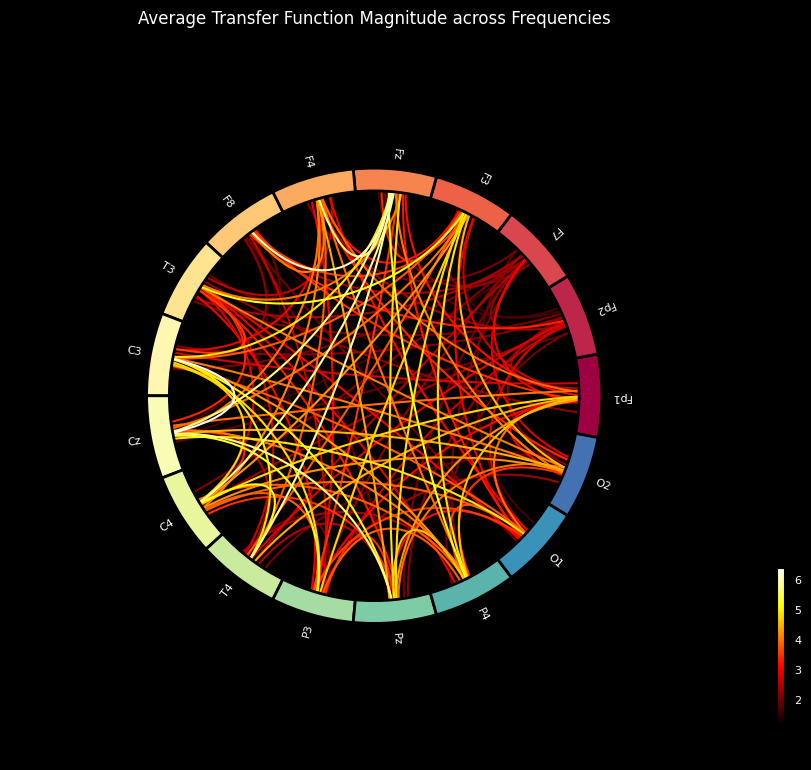

In [100]:
import numpy as np
from mne_connectivity.viz import plot_connectivity_circle

H_mag = np.abs(H)
con_2d = np.mean(H_mag, axis=2)
np.fill_diagonal(con_2d, 0)

fig, ax = plot_connectivity_circle(con_2d, ch_names, title="Average Transfer Function Magnitude across Frequencies")

In [101]:
con_2d.shape

(17, 17)

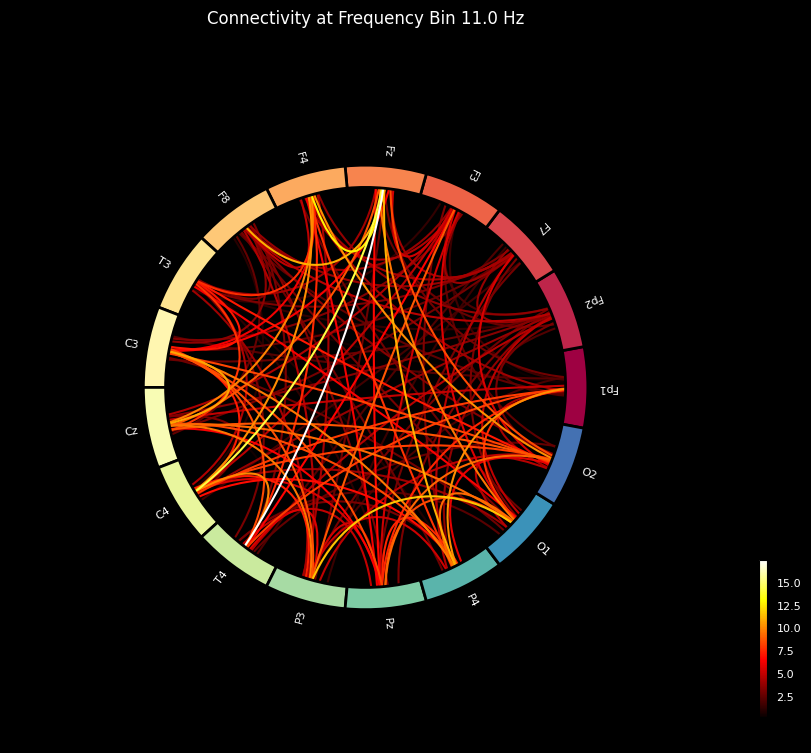

In [102]:
con_single_freq = np.abs(H[:, :, 10])
np.fill_diagonal(con_single_freq, 0)

fig, ax = plot_connectivity_circle(con_single_freq, ch_names, title=f"Connectivity at Frequency Bin {FREQS[10]} Hz")

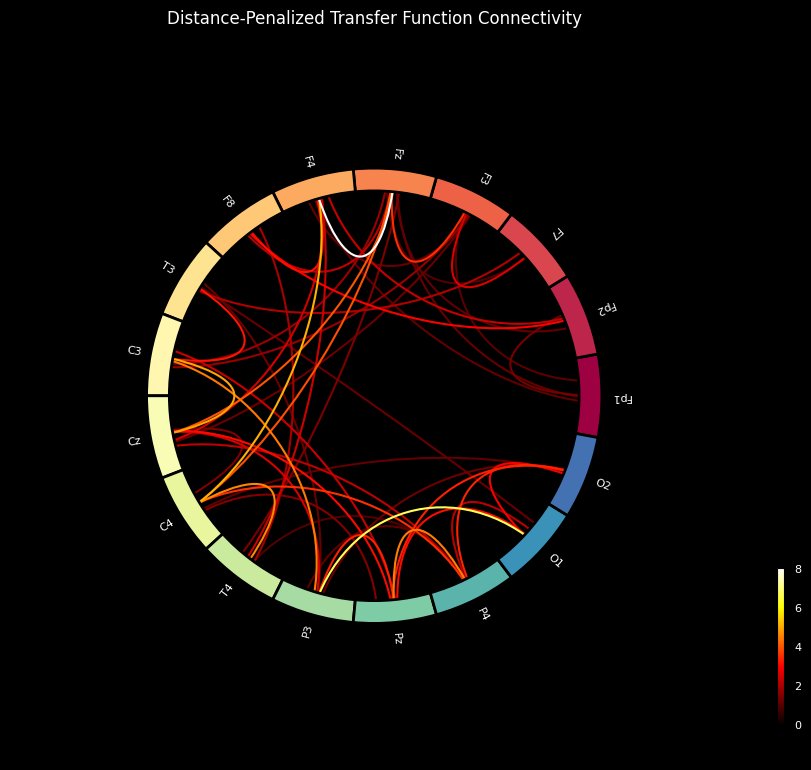

In [114]:
import scipy.spatial.distance as dist
locs = np.array([ch['loc'][:3] for ch in raw0.info['chs']])
dist_matrix = dist.squareform(dist.pdist(locs))

# Continuous Gaussian Decay: W_ij = exp(-D_ij^2 / (2 * sigma^2))
# Adjust sigma to control penalization strength (0.06m = 6 cm attenuation distance)
sigma = 0.06
weight_matrix = np.exp(-(dist_matrix ** 2) / (2 * (sigma ** 2)))

con_penalized = con_single_freq * weight_matrix
np.fill_diagonal(con_penalized, 0)


# ==========================================
fig, ax = plot_connectivity_circle(
    con_penalized,
    ch_names,
    n_lines=50,                             # Show top 50 connections
    title="Distance-Penalized Transfer Function Connectivity",
    colormap="hot",
    vmin=0,
    vmax=np.max(con_penalized)
)

plt.show()